In [1]:
import numpy as np
import jax
import jax.numpy as jnp

jax.config.update("jax_platform_name", "cpu")
from jax import vmap, jit
import matplotlib.pyplot as plt
import joblib
from qdots_qll.models import game
from qdots_qll import all_funcs
import seaborn as sns
import pandas as pd
import scipy
from functools import reduce
import os
import re
from scipy.stats import binned_statistic

import seaborn as sns


import matplotlib.font_manager as font_manager

import equinox as eqx

# from matplotlib import rcParams
from scipy.stats import binned_statistic


font = {"family": "Inter"}  # , 'weight': 'normal', 'size': 12}

# Aplica la fuente definida a Matplotlib
plt.rc("font", **font)

sns.set_palette("colorblind")

In [3]:
names_true = [
    "$\\gamma ( - \\eta)$",
    "$\\gamma ( + \\eta)$",
    "$S ( - \\eta)$",
    "$S ( +\\eta)$",
]
# names_hat = [
#     "$\\hat{\\gamma} ( + \\eta)$",
#     "$\\hat{S} ( - \\eta)$",
#     "$\\hat{S} ( +\\eta)$",
# ]

In [4]:
def compute_mean_one_run(cum_times_i, cov_arr_i, limites_bins):
    indices_bins = np.digitize(cum_times_i, limites_bins)
    means = np.array(
        [
            np.nanmean(cov_arr_i[indices_bins == i], axis=0)
            for i in range(1, len(limites_bins))
        ]
    )

    std_devs = np.array(
        [
            np.nanstd(cov_arr_i[indices_bins == i], axis=0)
            for i in range(1, len(limites_bins))
        ]
    )
    return means, std_devs


def get_binned_results_from_runs(
    times_array,
    cov_array,
    est_array,
    bin_step,
):
    dims_cov = cov_array[:, 1:].shape[2:]
    dims_est = est_array[:, 1:].shape[2:]

    cum_times = np.array(times_array[:, 1:]).cumsum(axis=1)
    cum_times_flatten = cum_times.flatten()
    cov_flatten = np.array(cov_array[:, 1:]).reshape(-1, *dims_cov)
    est_flatten = np.array(est_array[:, 1:]).reshape(-1, *dims_est)

    bins = np.arange(
        cum_times_flatten.min(), cum_times_flatten.max() + 1, bin_step
    )

    cov_mean_list = []
    cov_std_list = []

    for i in range(dims_cov[0]):
        cov_mean_row_list = []
        cov_std_row_list = []

        for j in range(dims_cov[1]):

            cov_mean_row_list.append(
                binned_statistic(
                    cum_times_flatten,
                    cov_flatten[:, i, j],
                    statistic="mean",
                    bins=bins,
                )[0]
            )
            cov_std_row_list.append(
                binned_statistic(
                    cum_times_flatten,
                    cov_flatten[:, i, j],
                    statistic="std",
                    bins=bins,
                )[0]
            )
        cov_mean_list.append(cov_mean_row_list)
        cov_std_list.append(cov_std_row_list)
    cov_mean_list = np.array(cov_mean_list).transpose(2, 1, 0)
    cov_std_list = np.array(cov_std_list).transpose(2, 1, 0)

    est_mean_list = []
    est_std_list = []

    for i in range(dims_est[0]):

        est_mean_list.append(
            binned_statistic(
                cum_times_flatten,
                est_flatten[
                    :,
                    i,
                ],
                statistic="mean",
                bins=bins,
            )[0]
        )
        est_std_list.append(
            binned_statistic(
                cum_times_flatten,
                est_flatten[
                    :,
                    i,
                ],
                statistic="std",
                bins=bins,
            )[0]
        )
    est_mean_list = np.array(est_mean_list).transpose(1, 0)
    est_std_list = np.array(est_std_list).transpose(1, 0)

    cum_times_binned, _, _ = binned_statistic(
        cum_times_flatten, cum_times_flatten, statistic="mean", bins=bins
    )
    return (
        cum_times_binned,
        cov_mean_list,
        cov_std_list,
        est_mean_list,
        est_std_list,
    )

In [5]:
def results_bin_single_run(times, covs, ests, no_bins):

    cum_times = np.array(times[1:]).cumsum()
    # bins = np.linspace(cum_times.min(), cum_times.max() + 1, no_bins)
    dims_cov = covs.shape[-2:]
    dims_est = ests.shape[-1:]

    cov_mean_list = []
    cov_std_list = []

    for i in range(dims_cov[0]):
        cov_mean_row_list = []
        cov_std_row_list = []

        for j in range(dims_cov[1]):

            cov_mean_row_list.append(
                binned_statistic(
                    cum_times,
                    covs[1:, i, j],
                    statistic="mean",
                    bins=no_bins,
                )[0]
            )
            cov_std_row_list.append(
                binned_statistic(
                    cum_times,
                    covs[1:, i, j],
                    statistic="std",
                    bins=no_bins,
                )[0]
            )
        cov_mean_list.append(cov_mean_row_list)
        cov_std_list.append(cov_std_row_list)
    cov_mean_list = np.array(cov_mean_list).transpose(2, 1, 0)
    cov_std_list = np.array(cov_std_list).transpose(2, 1, 0)

    est_mean_list = []
    est_std_list = []

    for i in range(dims_est[0]):

        est_mean_list.append(
            binned_statistic(
                cum_times,
                ests[
                    1:,
                    i,
                ],
                statistic="mean",
                bins=no_bins,
            )[0]
        )
        est_std_list.append(
            binned_statistic(
                cum_times,
                ests[
                    1:,
                    i,
                ],
                statistic="std",
                bins=no_bins,
            )[0]
        )
    est_mean_list = np.array(est_mean_list).transpose(1, 0)
    est_std_list = np.array(est_std_list).transpose(1, 0)

    cum_times_binned, _, _ = binned_statistic(
        cum_times, cum_times, statistic="mean", bins=no_bins
    )
    times_binned, _, _ = binned_statistic(
        cum_times, np.array(times[1:]), statistic="mean", bins=no_bins
    )
    return (
        times_binned,
        cum_times_binned,
        cov_mean_list,
        cov_std_list,
        est_mean_list,
        est_std_list,
    )

In [8]:
from qdots_qll.models import game


model = joblib.load("../results/run_2024-01-22_20:29:42_model.job")
true_parameters = game.true_pars
number_of_samples = 500

In [9]:
job_filenames = [
    "../results/run_2024-01-16_18:42:07_results.job",
    "../results/run_2024-01-17_11:07:58_results.job",
    "../results/run_2024-01-22_20:29:42_results.job",
]
# filenames = ["../results_cluster/one_qdot/" + i for i in filenames]
# job_filenames = list(filter(re.compile(".*job").match, filenames))
# log_filenames = list(filter(re.compile(".*log").match, filenames))

runs = [joblib.load(i) for i in job_filenames]

In [ ]:
# legend_array = [
#     "Random",
#     "Max det(FIM)",
#     "Max trace(FIM)",
#     "Random",
#     "Max det(FIM)",
#     "Max trace(FIM)",
# ]

In [69]:
results_binned = []

no_bins = 100
for i in range(len(runs)):
    run = runs[i]

    times_list = []
    cumtimes_list = []
    covmean_list = []
    covstd_list = []
    estmean_list = []
    eststd_list = []

    no_runs = run.iteration.shape[0]
    for k in range(no_runs):
        covs = run.cov_array[k]
        ests = run.estimates_array[k]
        times = run.times_array[k]

        re = results_bin_single_run(times, covs, ests, no_bins)

        times_list.append(re[0])
        cumtimes_list.append(re[1])
        covmean_list.append(re[2])
        covstd_list.append(re[3])
        estmean_list.append(re[4])
        eststd_list.append(re[5])

    times_list = np.array(times_list).mean(axis=0)
    cumtimes_list = np.array(cumtimes_list).mean(axis=0)
    covstd_list = np.array(covmean_list).std(axis=0)
    covmean_list = np.array(covmean_list).mean(axis=0)

    # covstd_list = np.array(covstd_list).mean(axis=0)

    eststd_list = np.array(estmean_list).std(axis=0)
    estmean_list = np.array(estmean_list).mean(axis=0)

    # eststd_list = np.array(eststd_list).mean(axis=0)

    # (
    #     cum_times_binned,
    #     cov_mean_list,
    #     cov_std_list,
    #     est_mean_list,
    #     est_std_list,
    # ) = get_binned_results_from_runs(
    #     runs[i].times_array, runs[i].cov_array, runs[i].estimates_array, 1000
    # )

    cov_dict = {
        "times": times_list,
        "cumtimes": cumtimes_list,
        "covmean": covmean_list,
        "covstd": covstd_list,
        "estmean": estmean_list,
        "eststd": eststd_list,
    }
    results_binned.append(cov_dict)


# for i in range(len(results_binned)):
#     times = results_binned[i]["times"]
#     # times = np.diff(cumtimes, prepend=0)
#     covmeans = results_binned[i]["covmean"]
#     estmeans = results_binned[i]["estmean"]

#     fisher_information_each_time = np.array(
#         jax.vmap(
#             lambda particle, time: m.fim(particle, time, ground_state_qdot),
#             in_axes=(0, 0),
#         )(estmeans, times)
#     )

#     det_fisher_information_each_time = np.array(
#         jax.vmap(lambda f: jnp.linalg.det(f))(fisher_information_each_time)
#     )

#     results_binned[i]["fishermeans"] = fisher_information_each_time
#     results_binned[i]["fisherdets"] = det_fisher_information_each_time

#     det_covs = np.array(jax.vmap(lambda f: jnp.linalg.det(f))(covmeans))
#     results_binned[i]["covdet"] = det_covs

In [70]:
len(results_binned)

3

In [71]:
results_binned[0].keys()

dict_keys(['times', 'cumtimes', 'covmean', 'covstd', 'estmean', 'eststd'])

In [ ]:
fig, axs = plt.subplots(4, 1, figsize=(5, 10), dpi=200)

for j, ax in enumerate(axs.flatten()):
    for i in range(3):
        ax.plot(
            results_binned[i]["cumtimes"],
            results_binned[i]["covmean"][:, j, j],
        )
        ax.fill_between(
            x=results_binned[i]["cumtimes"],
            y1=results_binned[i]["covmean"][:, j, j]
            + results_binned[i]["covstd"][:, j, j],
            y2=results_binned[i]["covmean"][:, j, j]
            - results_binned[i]["covstd"][:, j, j],
            alpha=0.3,
        )
        ax.loglog()

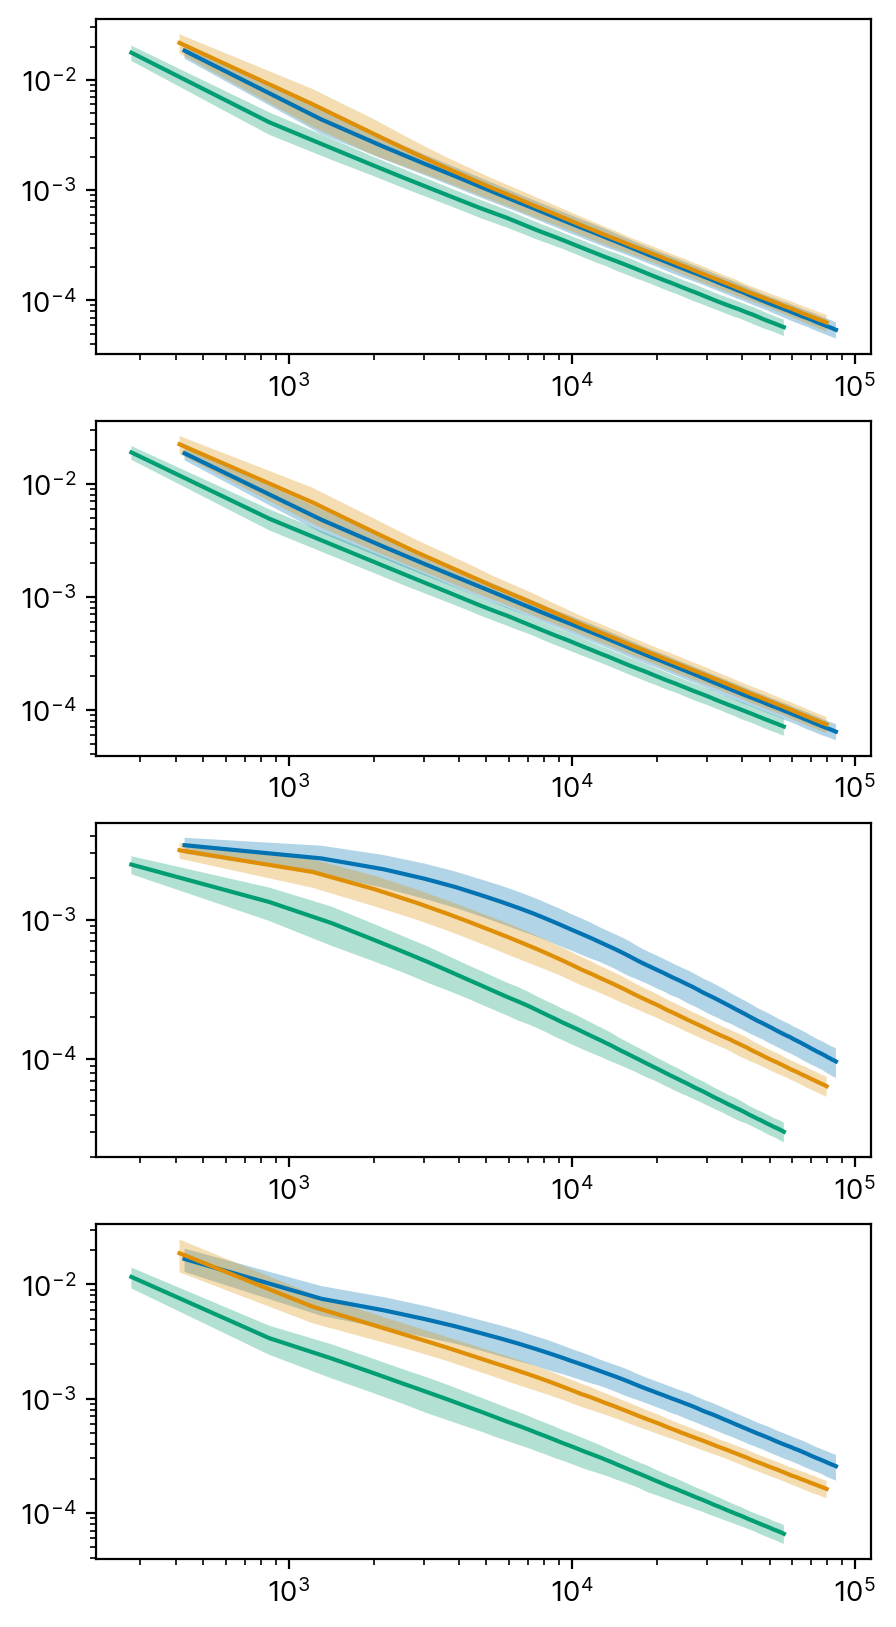

In [88]:
i = 1
j = 2

fig, axs = plt.subplots(4, 1, figsize=(5, 10), dpi=200)

for j, ax in enumerate(axs.flatten()):
    for i in range(3):
        ax.plot(
            results_binned[i]["cumtimes"],
            results_binned[i]["covmean"][:, j, j],
        )
        ax.fill_between(
            x=results_binned[i]["cumtimes"],
            y1=results_binned[i]["covmean"][:, j, j]
            + results_binned[i]["covstd"][:, j, j],
            y2=results_binned[i]["covmean"][:, j, j]
            - results_binned[i]["covstd"][:, j, j],
            alpha=0.3,
        )
        ax.loglog()

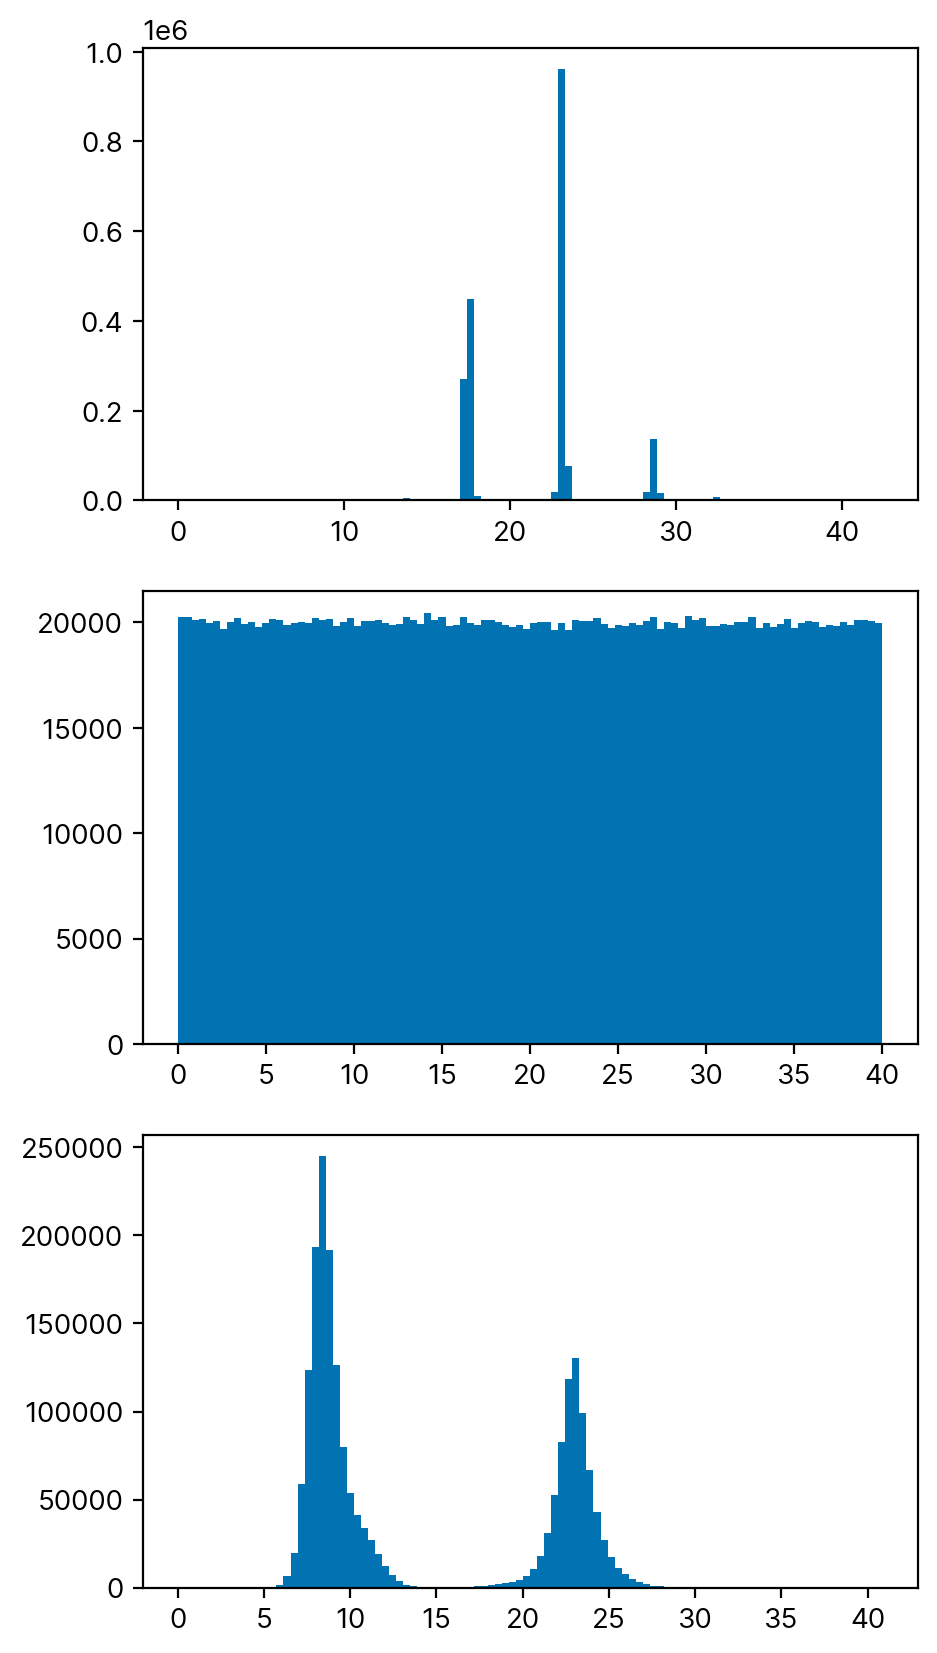

In [89]:
fig, axs = plt.subplots(3, 1, figsize=(5, 10), dpi=200)


for j, ax in enumerate(axs.flatten()):
    run = runs[j]
    ax.hist(np.array(run.times_array).flatten(), bins=100)

In [21]:
i = 1

run = runs[i]

In [47]:
mean_cov.shape

(3999, 4, 4)

In [46]:
mean_cov_std.shape

(3999, 4, 4)

In [48]:
cumtimes.shape

(3999,)

In [54]:
(mean_cov[:, 0, 0] + mean_cov_std[:, 0, 0]).shape

(3999,)

In [60]:
i =0 
run = runs[i]
cumtimes = run.times_array.cumsum(axis=1).mean(axis=0)[1:]

mean_cov = run.cov_array.mean(axis=0)[1:]
print(mean_cov.shape)
print(cumtimes.shape)

(3999, 4, 4)
(3999,)


[]

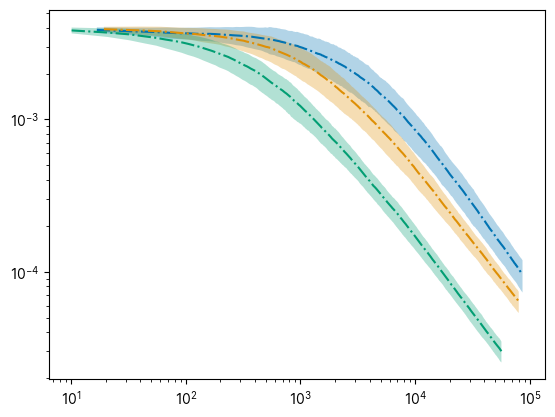

In [68]:
j = 2

for i in range(3):
    # print(i)
    run = runs[i]
    cumtimes = run.times_array.cumsum(axis=1).mean(axis=0)[1:]
    mean_cov = run.cov_array.mean(axis=0)[1:]
    mean_cov_std = np.nanstd(run.cov_array, axis=0)[1:]
    plt.plot(cumtimes, mean_cov[:, j, j], "-.")
    plt.fill_between(
        x=cumtimes[:],
        y1=mean_cov[:, j, j] - mean_cov_std[:, j, j],
        y2=mean_cov[:, j, j] + mean_cov_std[:, j, j], alpha=0.3
        
    )


plt.loglog()

In [34]:
run.times_array.cumsum(axis=1).mean(axis=0)


Array([0.0000000e+00, 1.9338818e+01, 3.9965034e+01, ..., 7.9882312e+04,
       7.9901477e+04, 7.9922492e+04], dtype=float32)

In [30]:
run.cov_array.mean(axis=0)[1:]

Array([[[ 5.8712583e-02,  3.2546460e-03,  1.4921669e-04, -1.6136841e-03],
        [ 3.2546450e-03,  5.8652703e-02,  7.8959754e-05, -9.9635194e-04],
        [ 1.4921678e-04,  7.8959776e-05,  3.9099869e-03,  1.0355782e-03],
        [-1.6136841e-03, -9.9635217e-04,  1.0355783e-03,  5.5838678e-02]],

       [[ 5.1747065e-02,  5.4668873e-03,  2.3093463e-04, -2.0363214e-03],
        [ 5.4668873e-03,  5.1681098e-02,  8.7694170e-05, -1.2546685e-03],
        [ 2.3093449e-04,  8.7694112e-05,  3.8431557e-03,  1.6914305e-03],
        [-2.0363212e-03, -1.2546687e-03,  1.6914306e-03,  4.8580404e-02]],

       [[ 4.6364397e-02,  6.6644312e-03,  2.6101436e-04, -1.7183669e-03],
        [ 6.6644321e-03,  4.7004979e-02,  8.8322478e-05, -1.1614588e-03],
        [ 2.6101430e-04,  8.8322522e-05,  3.7901611e-03,  2.1734808e-03],
        [-1.7183663e-03, -1.1614586e-03,  2.1734808e-03,  4.3192424e-02]],

       ...,

       [[ 6.2736588e-05,  2.4628462e-05,  3.8778039e-06,  7.9363590e-06],
        [ 2.4628551

In [20]:
results_binned[i]["covmean"].shape

(3000, 4, 4)

[]

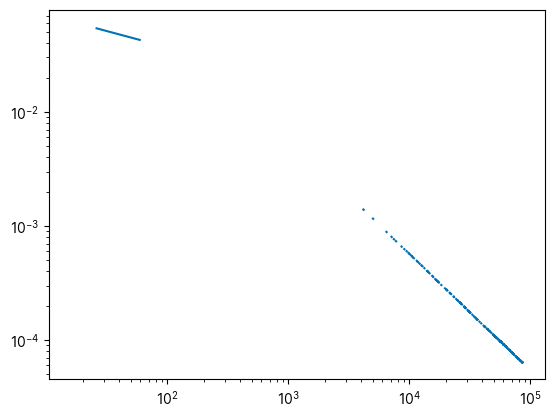

In [18]:
for i in range(3):
    plt.plot(results_binned[i]["cumtimes"], results_binned[i]["covmean"][:, 1, 1])
plt.loglog()